# Collapse of Data from Recursive Resampling with Replacement Bootstrapping


A recursive resampling based algorithm uses resampling with replacement iteratively, which leads to the shape of a distribution changing. However, since the boostrap retains the same number of points as the original sample, this means that this change in distribution leads to a collapse towards a single point.

This collapse is measured through changes in mean, standard deviation,variance, z-score, and skewness to measure the changes in data after utiilizing a resampling with replacement bootstrapping technique.

Changes in mean demonstrate shifting in the overall behavior of the data.

Changes in standard deviation and variance demonstrate the collapse of the function towards a single-point distrubtion. The standard deviation measures how far data is spread from the mean. Variance is the square of standard deviation, which measures how much the data points differ from the mean. The decay of these variables demonstrates the collapse of unique data after the use of resampling with replacement bootstrapping.

Changes in Z-score represent changes in the spread of the data. A small Z-score represents varied data that is spread far from the mean and unpredictable. A large Z-score represents predictable data that is close to the mean and lacks variation.

Changes in skewness demonstrate the shifting of the behavior of the data. Instead of retaining the shape of the original dataset, the nature of resampling and replacement drifts towards a normal distribution.

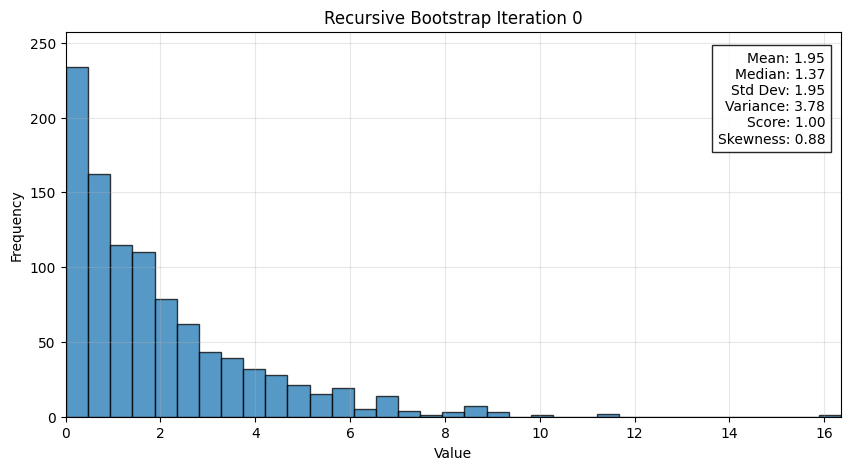

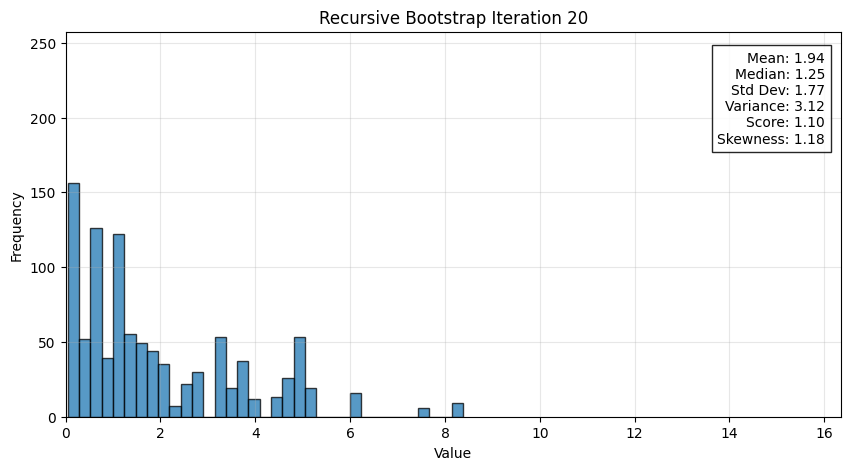

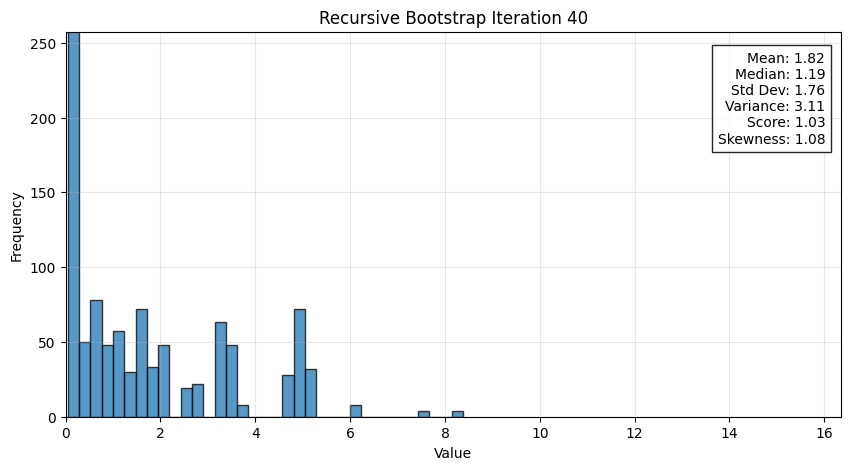

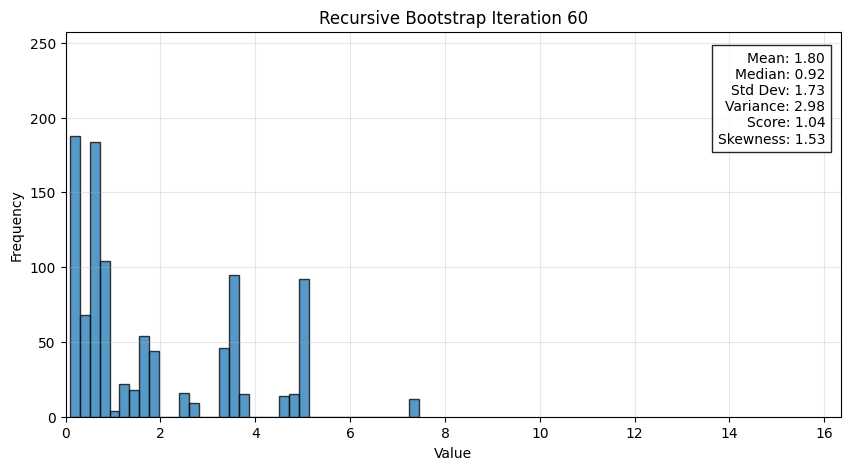

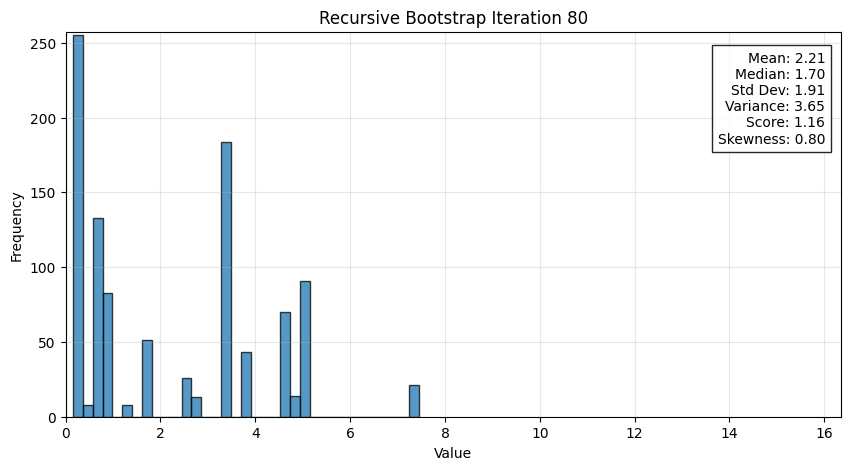

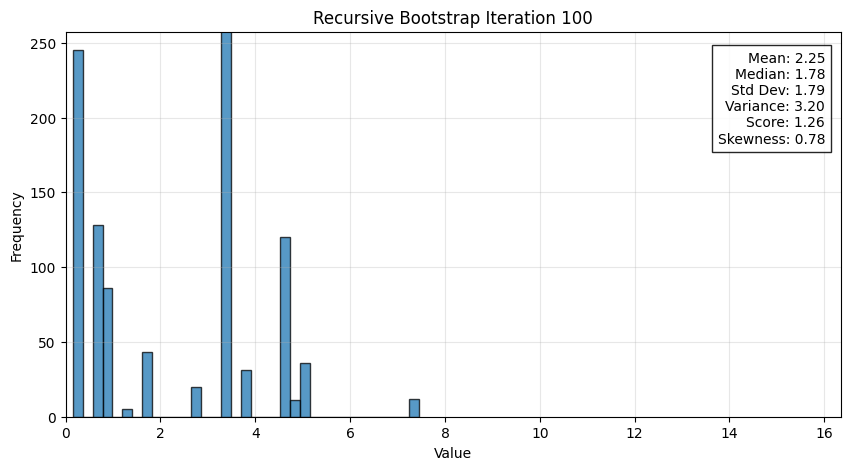

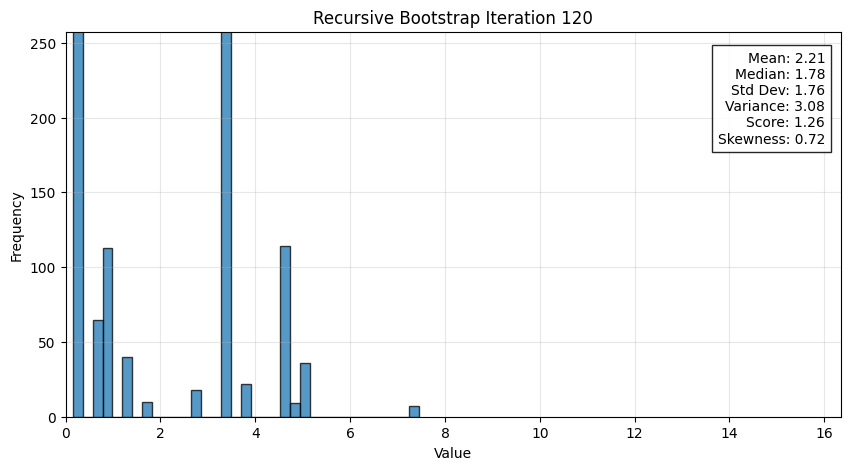

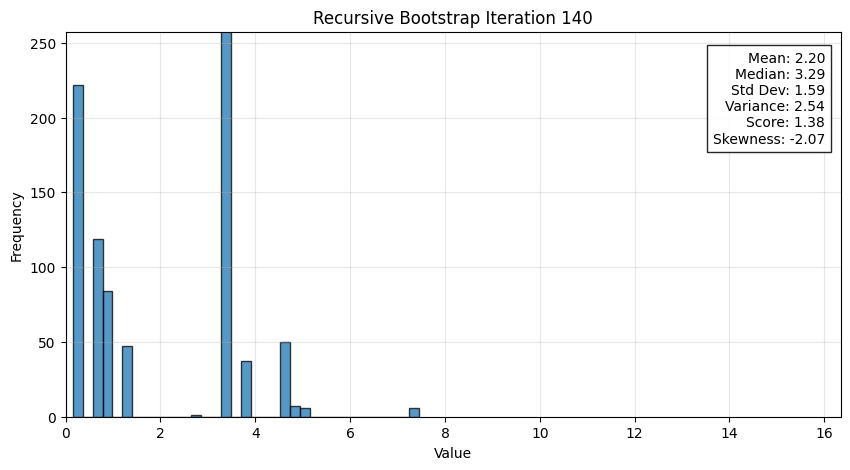

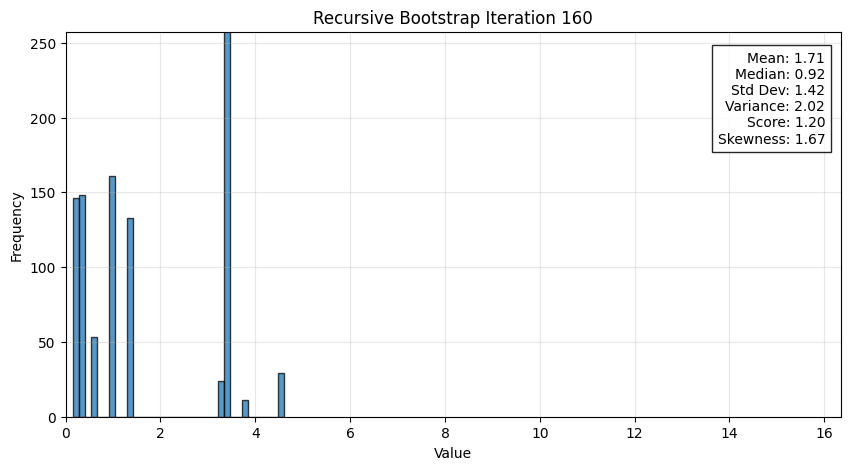

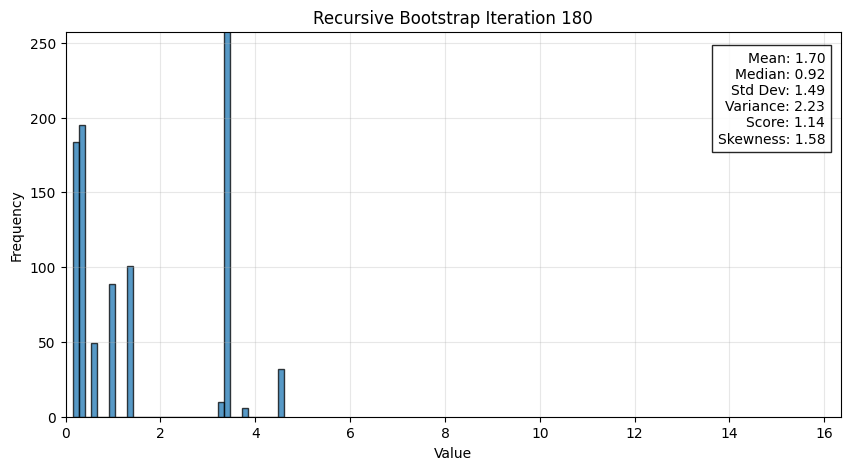

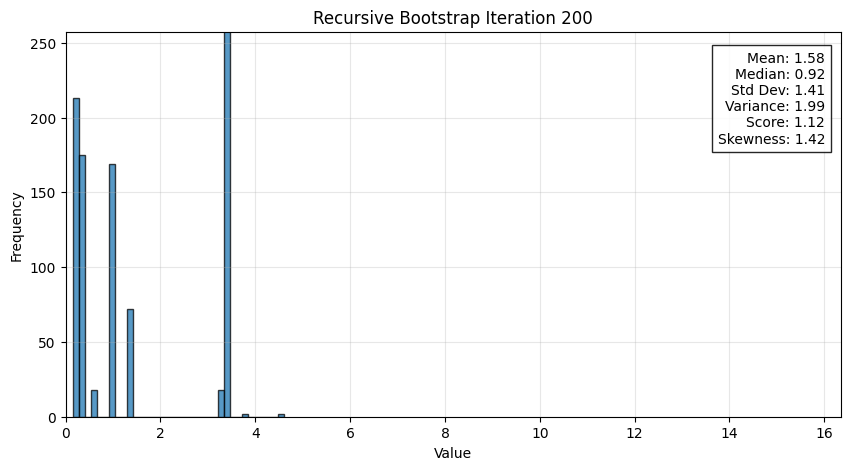

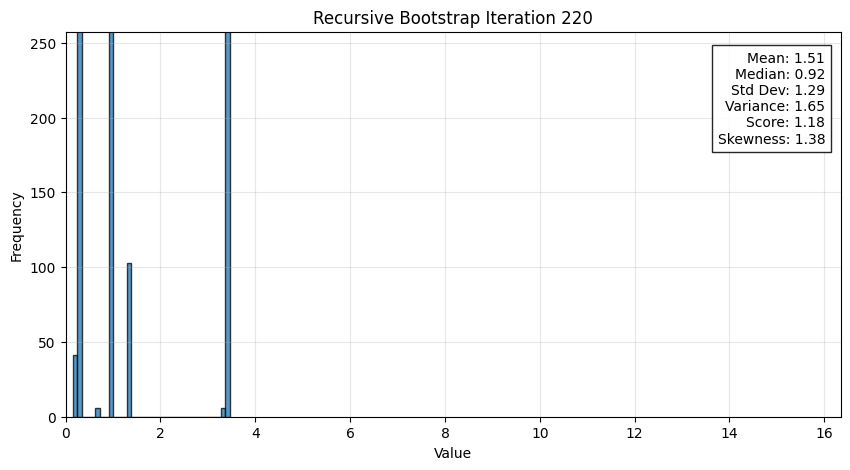

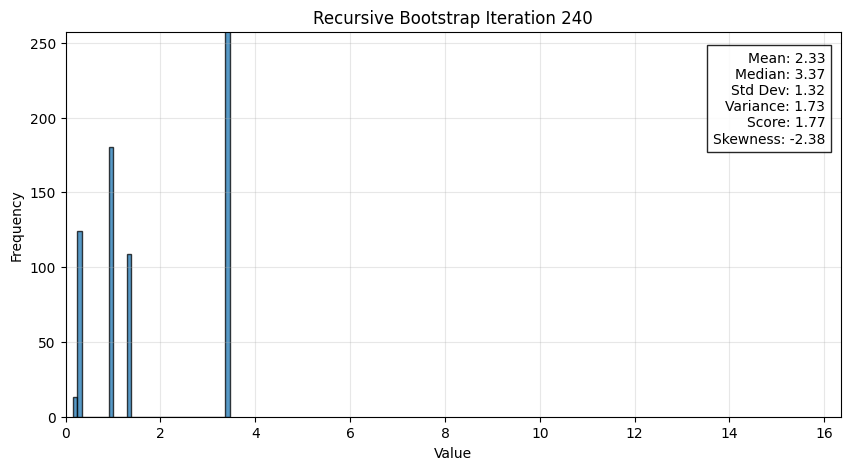

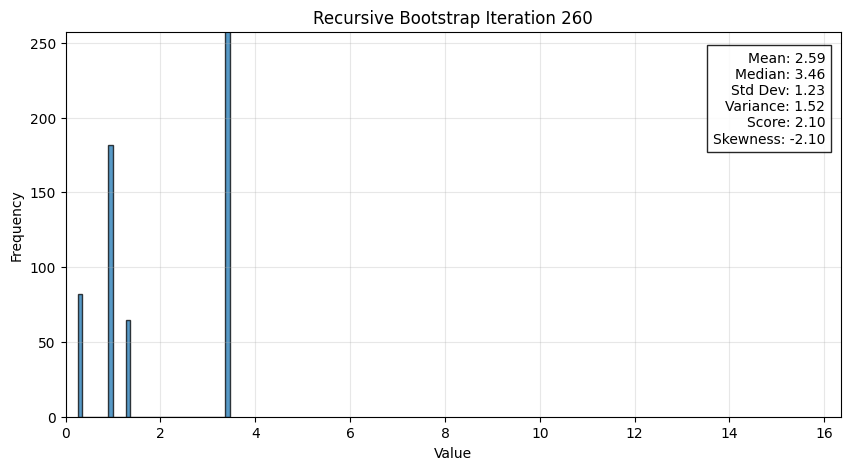

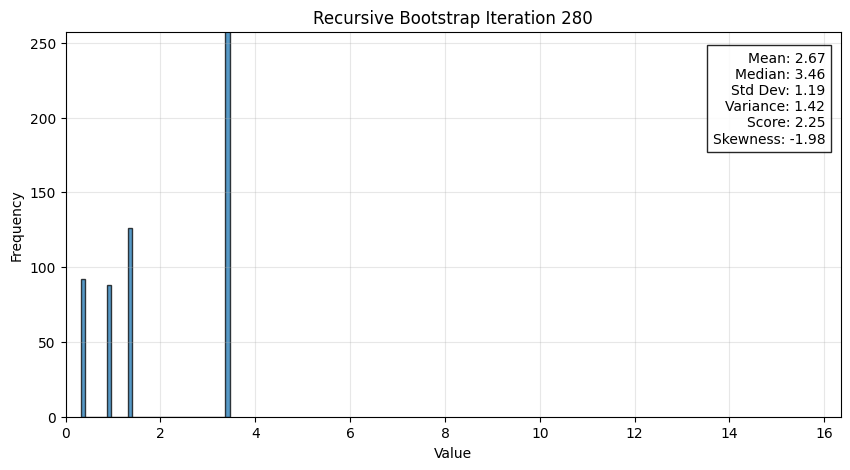

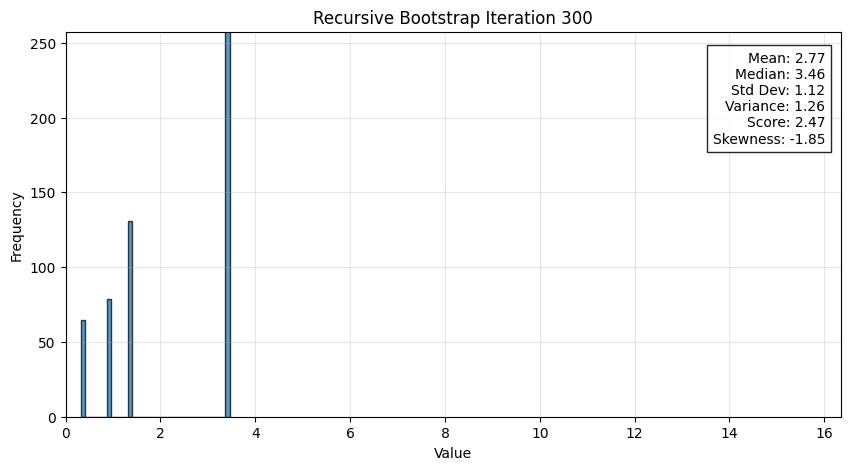

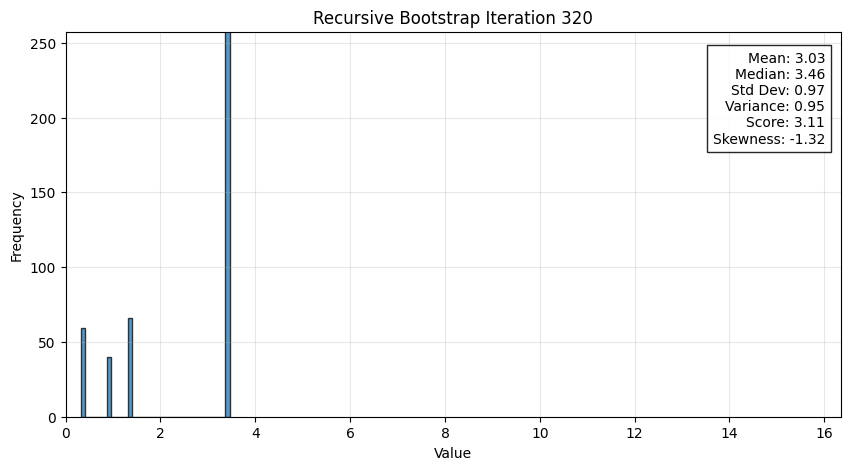

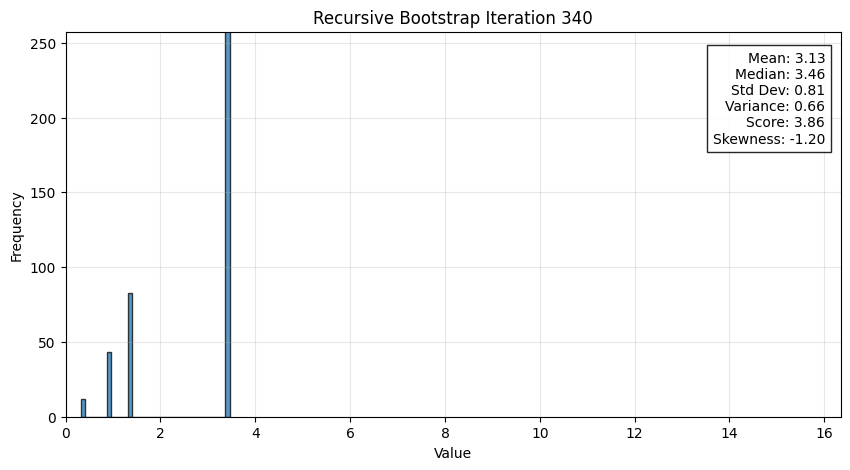

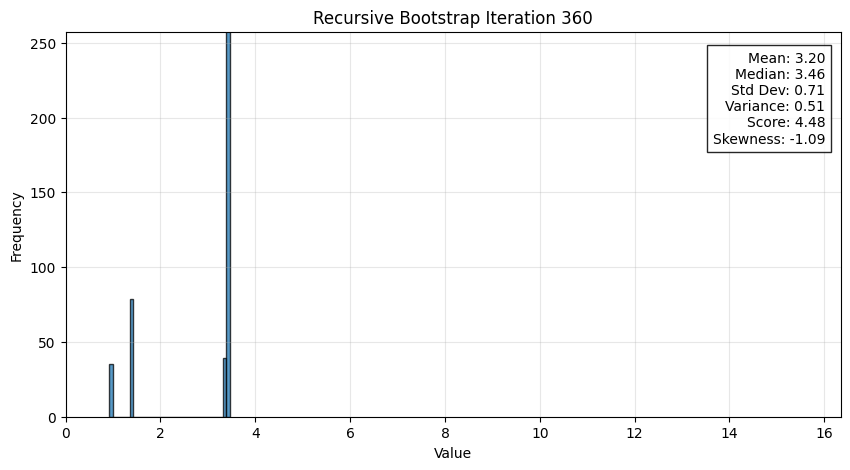

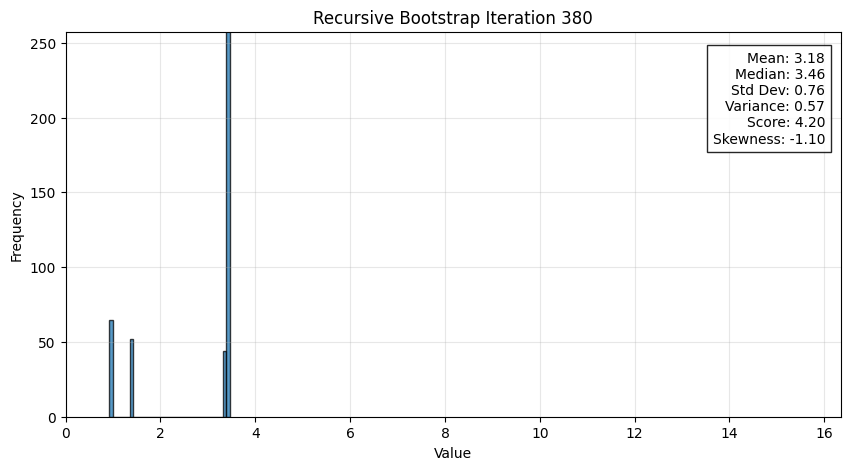

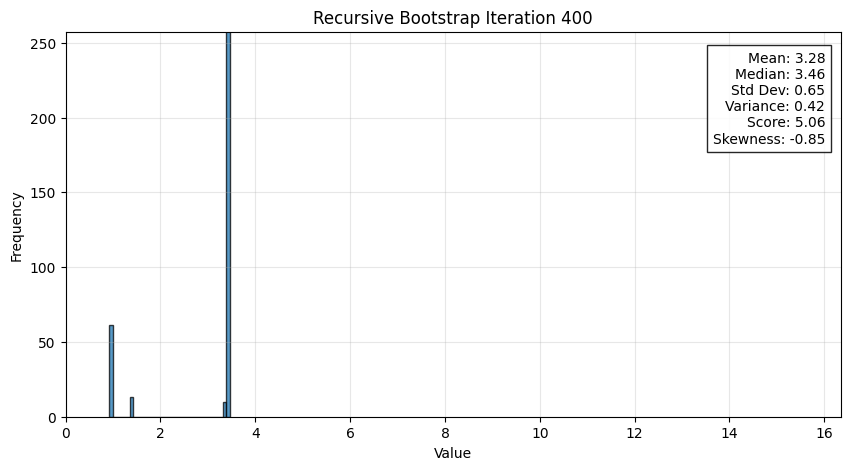

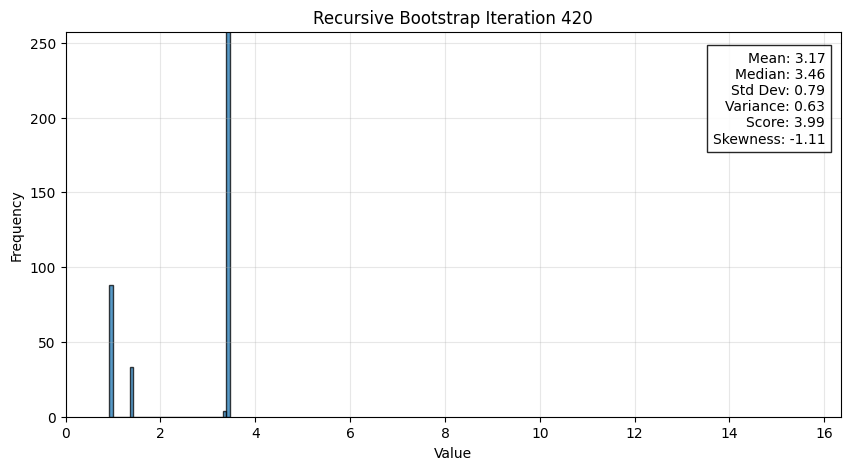

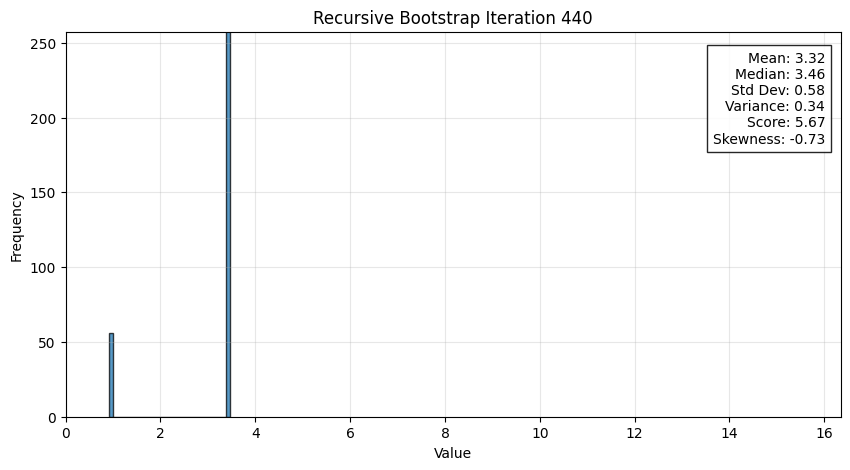

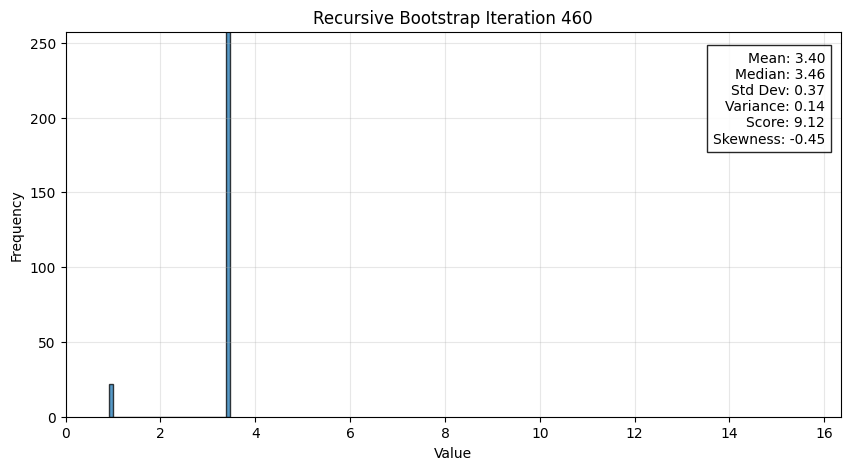

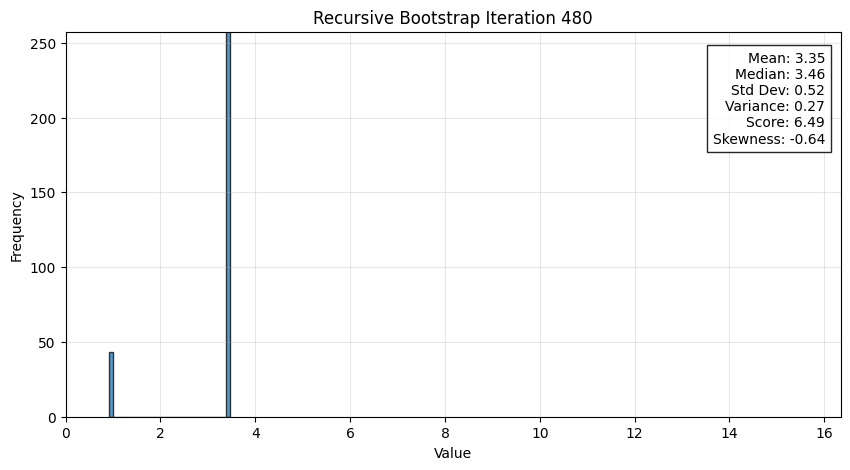

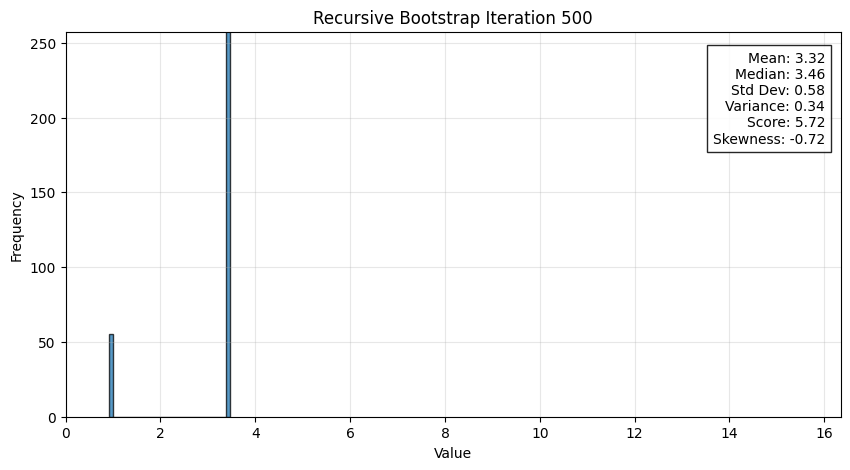

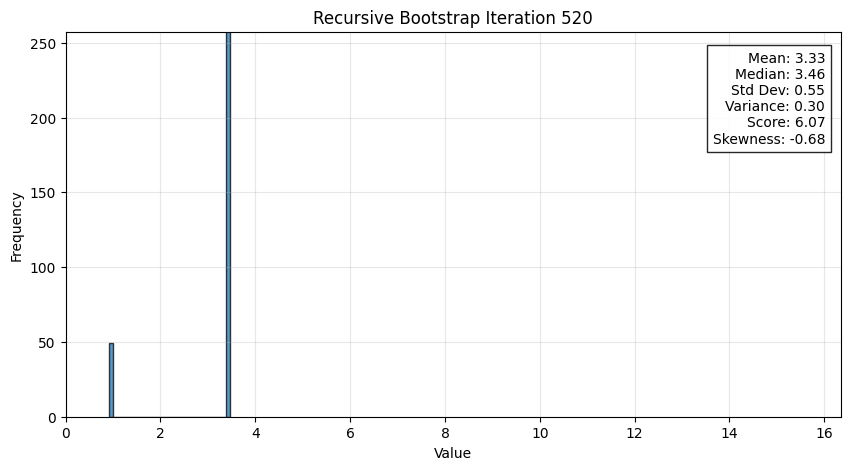

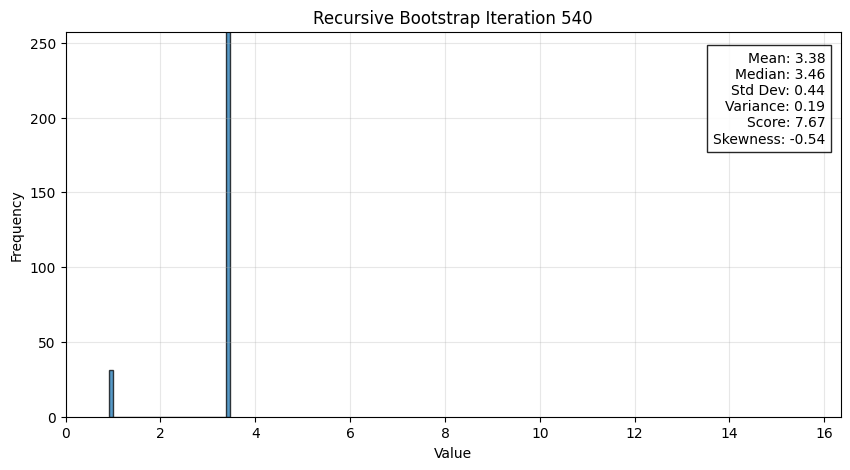

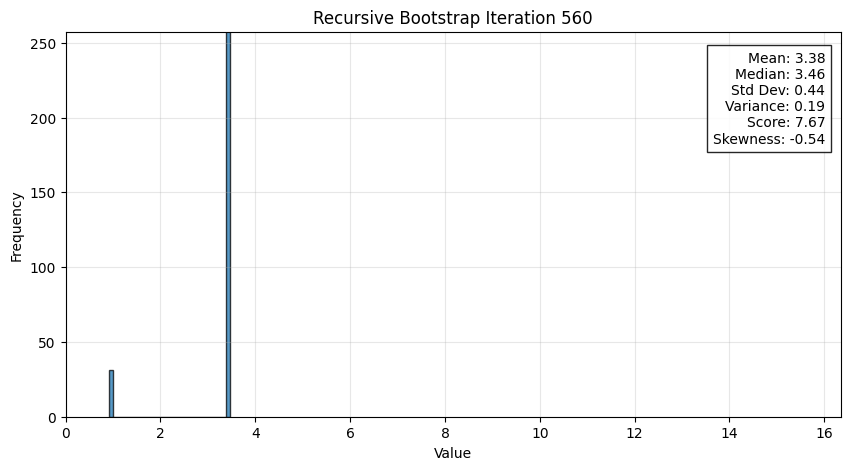

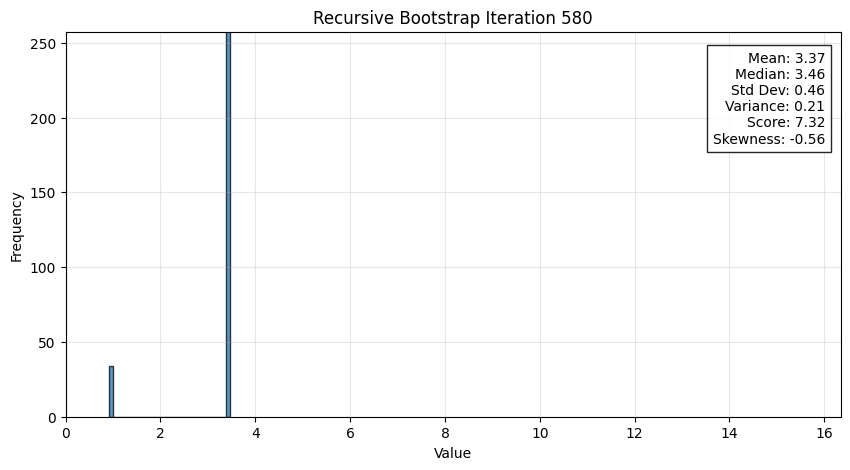

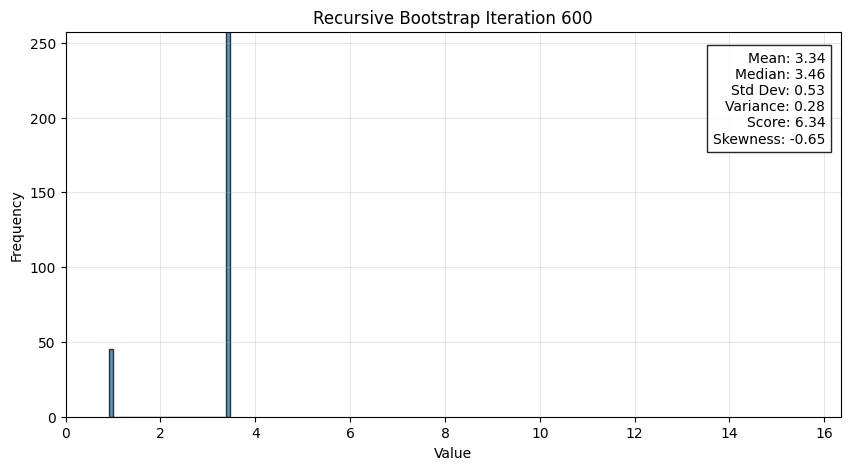

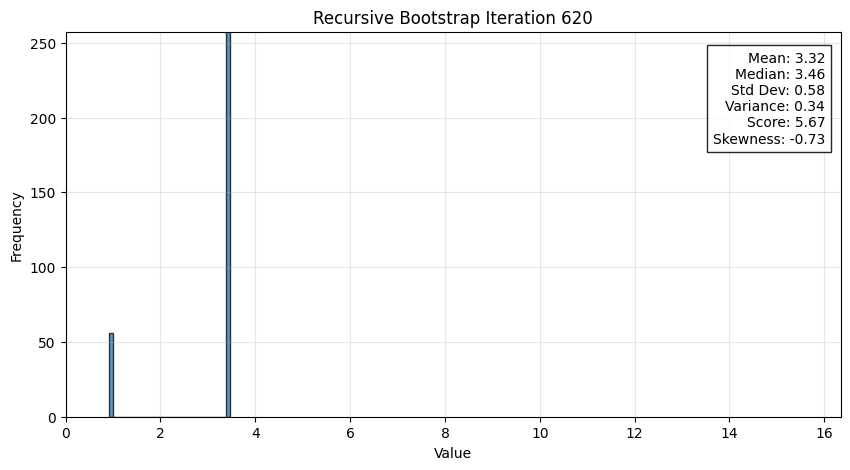

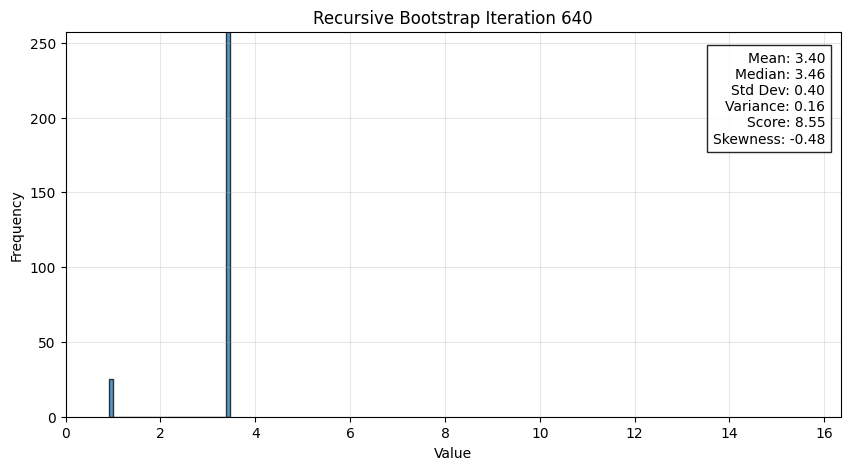

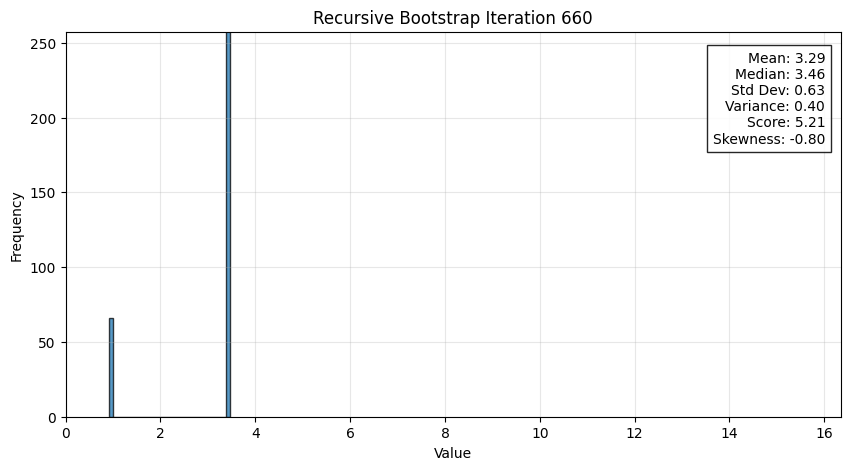

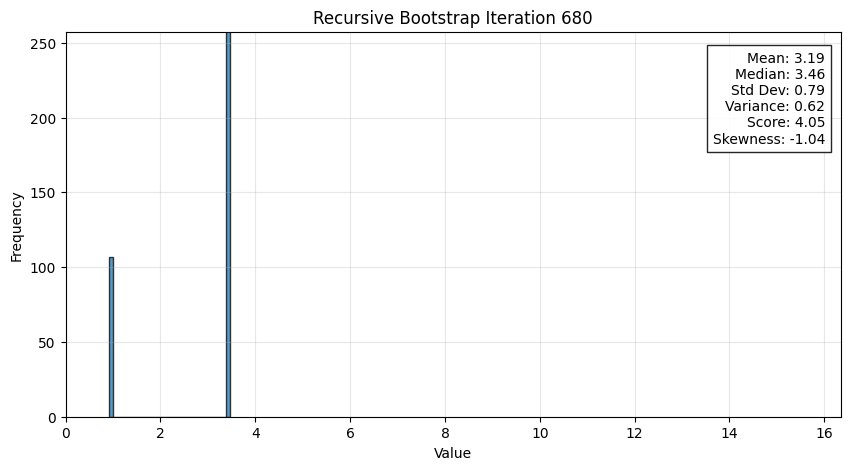

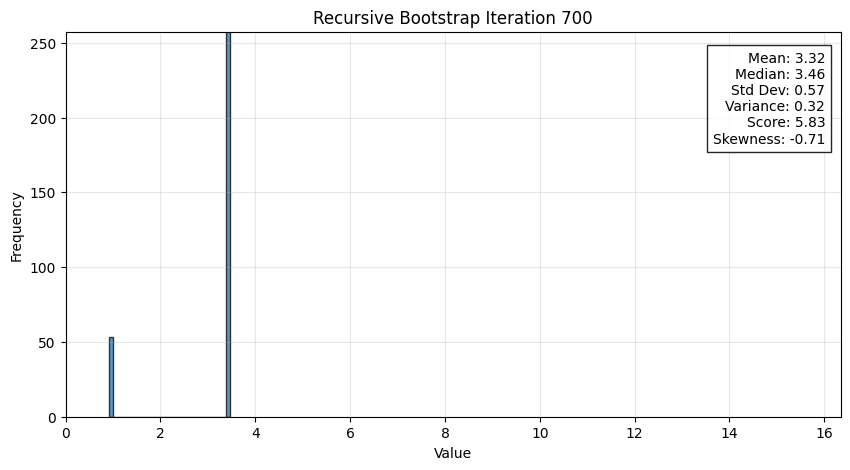

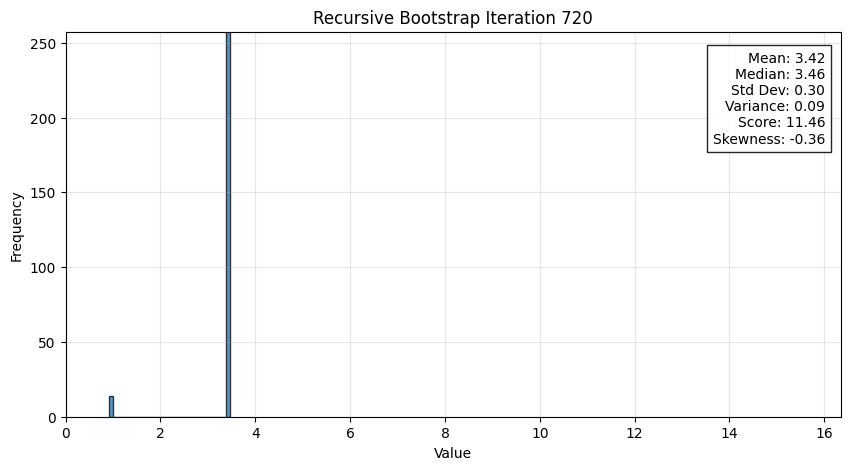

Empty DataFrame
Columns: []
Index: []


In [ ]:
# Recursive bootstrap of a skewed distribution
# Tracks mean, standard deviation, variance, score, and skewness
# Uses a FIXED x-axis scale for every histogram

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------
# SETTINGS
# -----------------------------------
np.random.seed(42)

sample_size = 1000
total_iterations = 720
display_every = 20

# -----------------------------------
# INITIAL SKEWED DATASET
# -----------------------------------
data = np.random.exponential(scale=2.0, size=sample_size)

# -----------------------------------
# FIXED X-AXIS SCALE
# -----------------------------------
x_min = 0
x_max = np.max(data)

# Optional: fixed y-axis scale
# Helps all histograms visually compare collapse
initial_counts, _ = np.histogram(data, bins=35)
y_max = np.max(initial_counts) * 1.1

# -----------------------------------
# STORE RESULTS
# -----------------------------------
results = []

# -----------------------------------
# RECURSIVE BOOTSTRAP LOOP
# -----------------------------------
for iteration in range(total_iterations + 1):

    # -----------------------------------
    # CALCULATE STATISTICS
    # -----------------------------------
    mean_val = np.mean(data)
    median_val = np.median(data)

    std_val = np.std(data, ddof=1)
    var_val = std_val**2

    # Pearson skewness coefficient
    skew_val = (
        3 * (mean_val - median_val) / std_val
        if std_val != 0 else 0
    )

    # Collapse metric
    score_val = (
        mean_val / std_val
        if std_val != 0 else 0
    )

    # Z-scores
    z_scores = (
        (data - mean_val) / std_val
        if std_val != 0 else np.zeros_like(data)
    )

    avg_z = np.mean(np.abs(z_scores))

    # -----------------------------------
    # SAVE RESULTS
    # -----------------------------------
    results.append({
        "Iteration": iteration,
        "Mean": mean_val,
        "Median": median_val,
        "Std Dev": std_val,
        "Variance": var_val,
        "Score": score_val,
        "Skewness": skew_val,
        "Average |Z|": avg_z
    })

    # -----------------------------------
    # DISPLAY HISTOGRAM
    # -----------------------------------
    if iteration % display_every == 0:

        plt.figure(figsize=(10, 5))

        plt.hist(
            data,
            bins=35,
            alpha=0.75,
            edgecolor='black'
        )

        # -----------------------------------
        # FORCE SAME AXIS SCALES
        # -----------------------------------
        plt.xlim(x_min, x_max)
        plt.ylim(0, y_max)

        # -----------------------------------
        # LABELS
        # -----------------------------------
        plt.title(f"Recursive Bootstrap Iteration {iteration}")
        plt.xlabel("Value")
        plt.ylabel("Frequency")

        # -----------------------------------
        # STATISTICS BOX
        # -----------------------------------
        stats_text = (
            f"Mean = {mean_val:.4f}\n"
            f"Median = {median_val:.4f}\n"
            f"Std Dev = {std_val:.4f}\n"
            f"Variance = {var_val:.4f}\n"
            f"Score = {score_val:.4f}\n"
            f"Skewness = {skew_val:.4f}\n"
            f"Avg |Z| = {avg_z:.4f}"
        )

        plt.text(
            0.98,
            0.95,
            stats_text,
            transform=plt.gca().transAxes,
            ha='right',
            va='top',
            bbox=dict(
                facecolor='white',
                alpha=0.85
            )
        )

        plt.grid(alpha=0.3)

        plt.show()

    # -----------------------------------
    # RECURSIVE RESAMPLING
    # -----------------------------------
    data = np.random.choice(
        data,
        size=len(data),
        replace=True
    )

# -----------------------------------
# CREATE DATAFRAME
# -----------------------------------
df = pd.DataFrame(results)

# -----------------------------------
# DISPLAY RESULTS TABLE
# -----------------------------------
print(df)


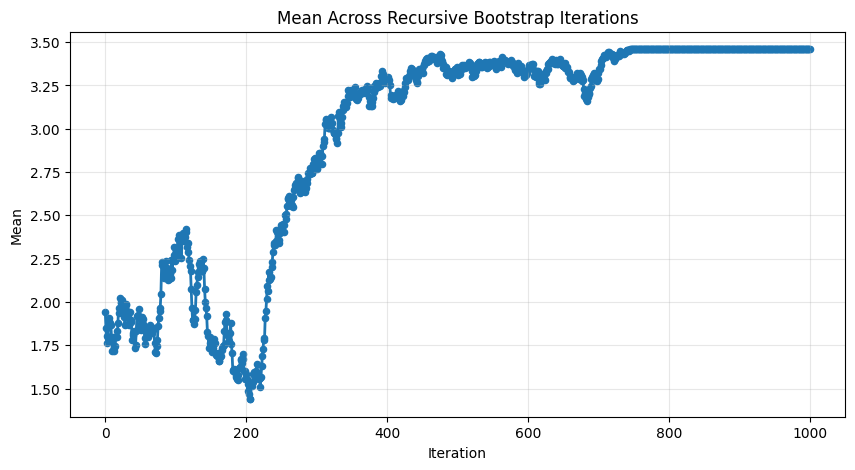

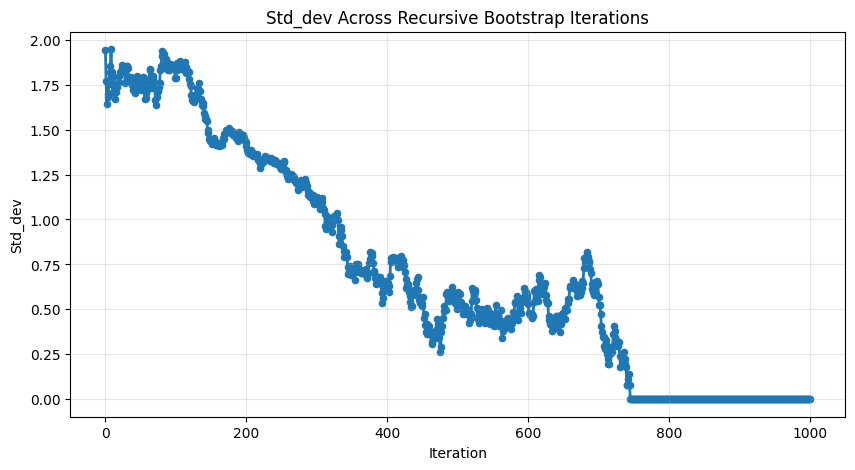

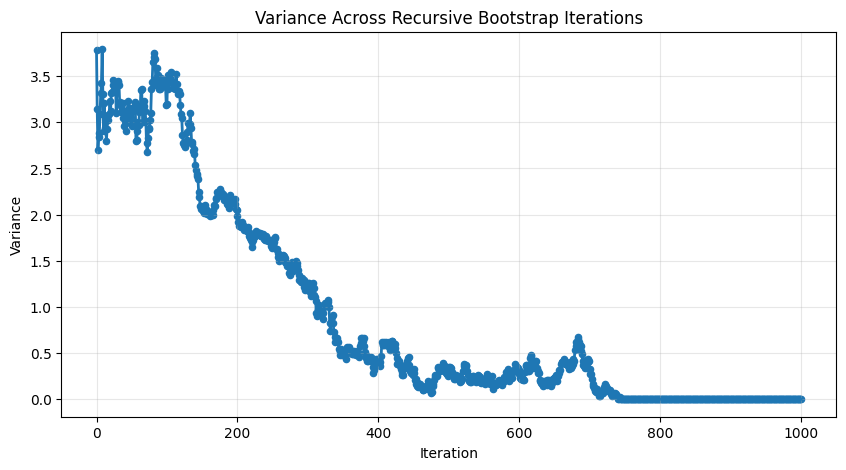

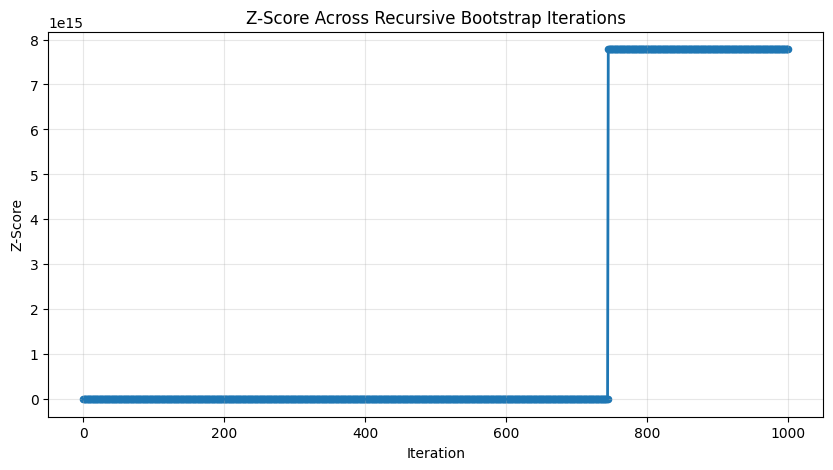

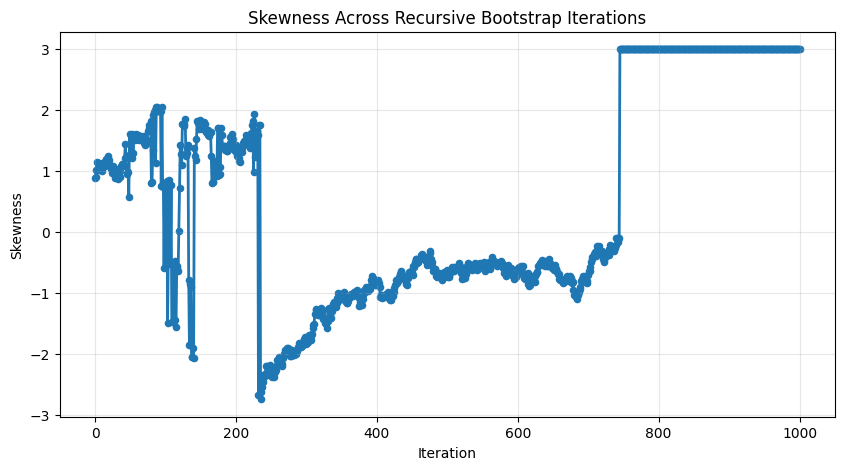

In [ ]:
# graph the calculated statistics in order
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------
# SETTINGS
# -----------------------------------
np.random.seed(42)
sample_size = 1000
total_iterations = 1000

# -----------------------------------
# INITIAL SKEWED DATASET
# -----------------------------------
data = np.random.exponential(scale=2.0, size=sample_size)

# -----------------------------------
# STORE RESULTS
# -----------------------------------
results = []

# -----------------------------------
# RECURSIVE BOOTSTRAP LOOP
# -----------------------------------
for iteration in range(total_iterations + 1):

    mean_val = np.mean(data)
    median_val = np.median(data)
    std_val = np.std(data, ddof=1)
    var_val = std_val**2

    # Pearson skewness coefficient
    skew_val = 3 * (mean_val - median_val) / std_val if std_val != 0 else 0

    # Score metric
    score_val = mean_val / std_val if std_val != 0 else 0

    results.append({
        "Iteration": iteration,
        "Mean": mean_val,
        "Std_dev": std_val,
        "Variance": var_val,
        "Z-Score": score_val,
        "Skewness": skew_val
    })

    # Recursive resampling
    data = np.random.choice(data, size=len(data), replace=True)

# -----------------------------------
# CREATE DATAFRAME
# -----------------------------------
df = pd.DataFrame(results)

# -----------------------------------
# GRAPH STATISTICS IN ORDER
# -----------------------------------
stats = ["Mean", "Std_dev", "Variance", "Z-Score","Skewness"]

for stat in stats:
    plt.figure(figsize=(10,5))
    plt.plot(df["Iteration"], df[stat], linewidth=2)
    plt.scatter(df["Iteration"], df[stat], s=20)
    plt.title(f"{stat} Across Recursive Bootstrap Iterations")
    plt.xlabel("Iteration")
    plt.ylabel(stat)
    plt.grid(True, alpha=0.3)
    plt.show()

# The First Order Spring-Mass System Differential Equation

my''+cy'+ky=0

This equation traditionally describes the motion of an object in a damped spring mass system, however this general equation can also be used to describe a oscillatory system that approaches a steady state. Thus, this can be cross applied and used in representing a system that slowly collapses towards a singular data point.

Model Goodness of Fit:
Variance Model R² = 0.974037
Standard Deviation Model R² = 0.949554
Change in Mean Model R² = 0.914914


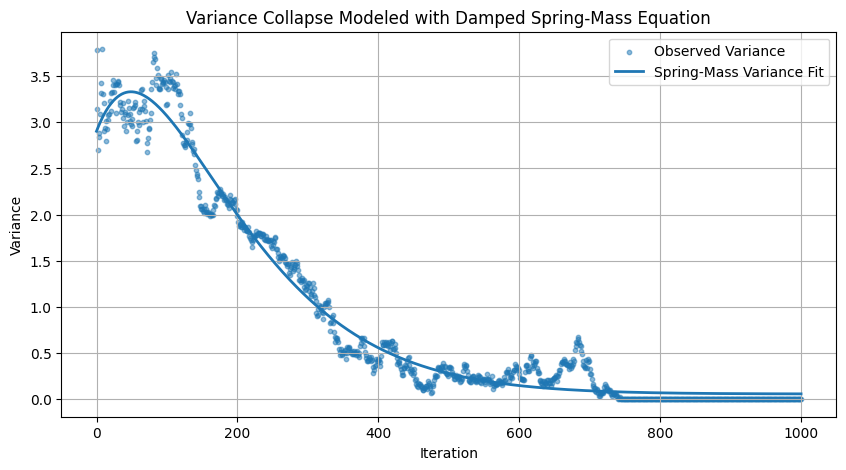

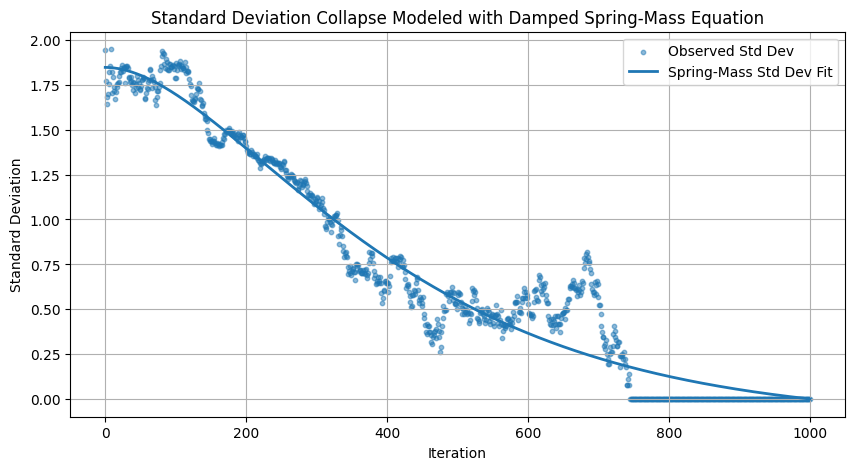

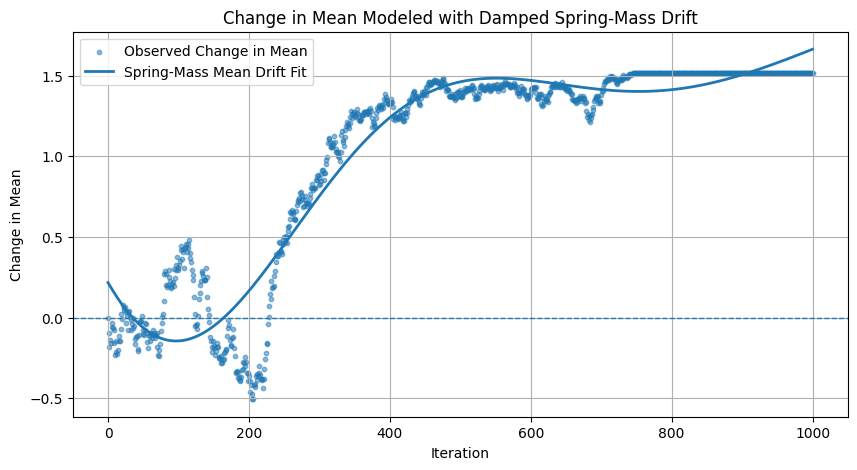


Generic Spring-Mass Differential Equation:
m y'' + c y' + k y = 0

Underdamped Solution Form Used:
y(t) = A e^(-alpha t) cos(omega t + phi) + C

Variance Model Parameters:
A = 16.518345
alpha = 8.628784
omega = 2.737348
phi = -1.397644
C = 0.057295

Standard Deviation Model Parameters:
A = 397.591986
alpha = 4.517881
omega = 0.022269
phi = -1.565859
C = -0.116693

Change in Mean Model Parameters:
A = 1.239212
alpha = 2.759132
omega = 8.291787
phi = -4.399901
C = 0.598378
D = 1.122699

Variance Collapse Model:
Variance(t) = 16.5183e^(-8.6288t)cos(2.7373t + -1.3976) + 0.0573

Standard Deviation Collapse Model:
StdDev(t) = 397.5920e^(-4.5179t)cos(0.0223t + -1.5659) + -0.1167

Change in Mean Drift Model:
ΔMean(t) = 1.2392e^(-2.7591t)cos(8.2918t + -4.3999) + 1.1227t + 0.5984


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# 1. GENERATE RECURSIVE BOOTSTRAP DATA
# ============================================================

np.random.seed(42)

sample_size = 1000
total_iterations = 1000

data = np.random.exponential(scale=2.0, size=sample_size)
results = []

for iteration in range(total_iterations + 1):
    mean_val = np.mean(data)
    std_val = np.std(data, ddof=1)
    var_val = std_val**2

    results.append({
        "Iteration": iteration,
        "Mean": mean_val,
        "Std Dev": std_val,
        "Variance": var_val
    })

    data = np.random.choice(data, size=len(data), replace=True)

df = pd.DataFrame(results)

# ============================================================
# 2. DEFINE VARIABLES
# ============================================================

t = df["Iteration"].values.astype(float)

# normalize time to avoid numerical fitting issues
t_norm = t / np.max(t)

variance = df["Variance"].values
std_dev = df["Std Dev"].values
mean_vals = df["Mean"].values
change_mean = mean_vals - mean_vals[0]

# ============================================================
# 3. SPRING-MASS MODEL FUNCTIONS
# ============================================================

def spring_mass_collapse(t, A, alpha, omega, phi, C):
    """
    Damped spring-mass collapse model.

    Based on:
        m y'' + c y' + k y = 0

    Underdamped solution:
        y(t) = A e^(-alpha t) cos(omega t + phi) + C

    where:
        alpha = c / (2m)
        omega = damped angular frequency
        C = nonzero baseline
    """
    return A * np.exp(-alpha * t) * np.cos(omega * t + phi) + C


def spring_mass_mean_drift(t, A, alpha, omega, phi, C, D):
    """
    Damped spring-mass model with linear drift.

    This is better for mean change because the mean may drift instead
    of purely collapsing.
    """
    spring_part = A * np.exp(-alpha * t) * np.cos(omega * t + phi)
    drift_part = D * t
    return spring_part + drift_part + C


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

# ============================================================
# 4. FIT VARIANCE AND STANDARD DEVIATION MODELS
# ============================================================

p0_var = [
    variance[0] - variance[-1],  # A
    3.0,                         # alpha
    20.0,                        # omega
    0.0,                         # phi
    variance[-1]                 # C
]

p0_std = [
    std_dev[0] - std_dev[-1],     # A
    3.0,                         # alpha
    20.0,                        # omega
    0.0,                         # phi
    std_dev[-1]                  # C
]

bounds_collapse = (
    [-np.inf, 0, 0, -2*np.pi, -np.inf],
    [ np.inf, np.inf, np.inf, 2*np.pi, np.inf]
)

params_var, _ = curve_fit(
    spring_mass_collapse,
    t_norm,
    variance,
    p0=p0_var,
    bounds=bounds_collapse,
    maxfev=50000
)

params_std, _ = curve_fit(
    spring_mass_collapse,
    t_norm,
    std_dev,
    p0=p0_std,
    bounds=bounds_collapse,
    maxfev=50000
)

variance_fit = spring_mass_collapse(t_norm, *params_var)
std_fit = spring_mass_collapse(t_norm, *params_std)

# ============================================================
# 5. FIT CHANGE-IN-MEAN MODEL
# ============================================================

p0_change_mean = [
    0.01,                         # A
    2.0,                          # alpha
    20.0,                         # omega
    0.0,                          # phi
    change_mean[0],               # C
    change_mean[-1] - change_mean[0]  # D
]

bounds_mean = (
    [-np.inf, 0, 0, -2*np.pi, -np.inf, -np.inf],
    [ np.inf, np.inf, np.inf, 2*np.pi, np.inf, np.inf]
)

params_change_mean, _ = curve_fit(
    spring_mass_mean_drift,
    t_norm,
    change_mean,
    p0=p0_change_mean,
    bounds=bounds_mean,
    maxfev=50000
)

change_mean_fit = spring_mass_mean_drift(t_norm, *params_change_mean)

# ============================================================
# 6. R² VALUES
# ============================================================

r2_variance = r_squared(variance, variance_fit)
r2_std = r_squared(std_dev, std_fit)
r2_change_mean = r_squared(change_mean, change_mean_fit)

print("Model Goodness of Fit:")
print(f"Variance Model R² = {r2_variance:.6f}")
print(f"Standard Deviation Model R² = {r2_std:.6f}")
print(f"Change in Mean Model R² = {r2_change_mean:.6f}")

# ============================================================
# 7. PLOTS
# ============================================================

plt.figure(figsize=(10, 5))
plt.scatter(t, variance, s=10, alpha=0.5, label="Observed Variance")
plt.plot(t, variance_fit, lw=2, label="Spring-Mass Variance Fit")
plt.xlabel("Iteration")
plt.ylabel("Variance")
plt.title("Variance Collapse Modeled with Damped Spring-Mass Equation")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(t, std_dev, s=10, alpha=0.5, label="Observed Std Dev")
plt.plot(t, std_fit, lw=2, label="Spring-Mass Std Dev Fit")
plt.xlabel("Iteration")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation Collapse Modeled with Damped Spring-Mass Equation")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(t, change_mean, s=10, alpha=0.5, label="Observed Change in Mean")
plt.plot(t, change_mean_fit, lw=2, label="Spring-Mass Mean Drift Fit")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel("Change in Mean")
plt.title("Change in Mean Modeled with Damped Spring-Mass Drift")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 8. PRINT FITTED PARAMETERS
# ============================================================

print("\nGeneric Spring-Mass Differential Equation:")
print("m y'' + c y' + k y = 0")

print("\nUnderdamped Solution Form Used:")
print("y(t) = A e^(-alpha t) cos(omega t + phi) + C")

print("\nVariance Model Parameters:")
A, alpha, omega, phi, C = params_var
print(f"A = {A:.6f}")
print(f"alpha = {alpha:.6f}")
print(f"omega = {omega:.6f}")
print(f"phi = {phi:.6f}")
print(f"C = {C:.6f}")

print("\nStandard Deviation Model Parameters:")
A, alpha, omega, phi, C = params_std
print(f"A = {A:.6f}")
print(f"alpha = {alpha:.6f}")
print(f"omega = {omega:.6f}")
print(f"phi = {phi:.6f}")
print(f"C = {C:.6f}")

print("\nChange in Mean Model Parameters:")
A, alpha, omega, phi, C, D = params_change_mean
print(f"A = {A:.6f}")
print(f"alpha = {alpha:.6f}")
print(f"omega = {omega:.6f}")
print(f"phi = {phi:.6f}")
print(f"C = {C:.6f}")
print(f"D = {D:.6f}")

# ============================================================
# 9. DISPLAY FITTED EQUATIONS
# ============================================================

A, alpha, omega, phi, C = params_var
print("\nVariance Collapse Model:")
print(
    f"Variance(t) = {A:.4f}e^(-{alpha:.4f}t)"
    f"cos({omega:.4f}t + {phi:.4f}) + {C:.4f}"
)

A, alpha, omega, phi, C = params_std
print("\nStandard Deviation Collapse Model:")
print(
    f"StdDev(t) = {A:.4f}e^(-{alpha:.4f}t)"
    f"cos({omega:.4f}t + {phi:.4f}) + {C:.4f}"
)

A, alpha, omega, phi, C, D = params_change_mean
print("\nChange in Mean Drift Model:")
print(
    f"ΔMean(t) = {A:.4f}e^(-{alpha:.4f}t)"
    f"cos({omega:.4f}t + {phi:.4f}) + {D:.4f}t + {C:.4f}"
)

# Acknowledgement of Assistance
ChatGPT. Assistance given to the author, generative AI. ChatGPT aided in the coding and development of the various graphs used in this project as well as the use of the recursive bootstrap. This was used to aid in my research of the recursive bootstrap in relation to neural network collapse. https://chatgpt.com/share/6a03e27e-a3f0-83ea-92fe-9694d77d2c78